In [2]:
import numpy as np
population = np.random.rand(10,1000,5000)
print('population mean is : ',np.mean(population))

population mean is :  0.499949139905372


In [3]:
population[0][0].ndim

1

In [4]:
# samples
sample_1 = np.random.choice(population[0][0],50)
sample_2 = np.random.choice(population[0][0],50)
sample_3 = np.random.choice(population[0][0],50)
print(np.mean(sample_1))
print(np.mean(sample_2))
print(np.mean(sample_3))

(np.mean(sample_1) + np.mean(sample_2) + np.mean(sample_3))/3

0.482756038082239
0.5123030401600769
0.5273198865833408


np.float64(0.5074596549418856)

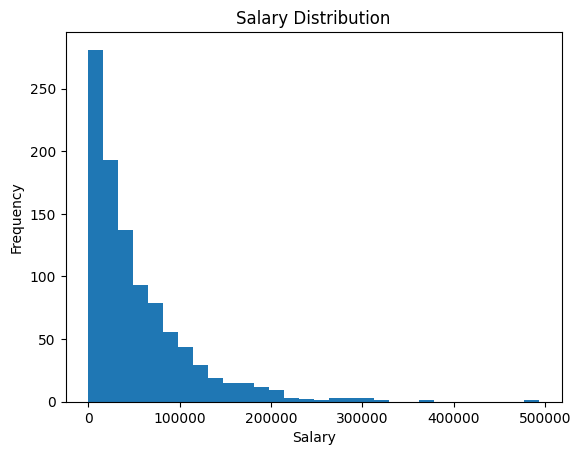

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# salary as a columns  : salary will look skewed data
salary = np.random.exponential(scale=50000, size=1000)
plt.hist(salary, bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

In [6]:
# salary mean
print('Salary Mean : ', np.mean(salary))

Salary Mean :  53851.82328463745


In [7]:
# samples from salary data
s1 = np.random.choice(salary, 50)
s2 = np.random.choice(salary, 50)
s3 = np.random.choice(salary, 50)

# compute the samples mean
avg_sample_mean = (np.mean(s1) + np.mean(s2) + np.mean(s3))/3
print('Average of Sample Means : ', avg_sample_mean)

Average of Sample Means :  52263.00263521028


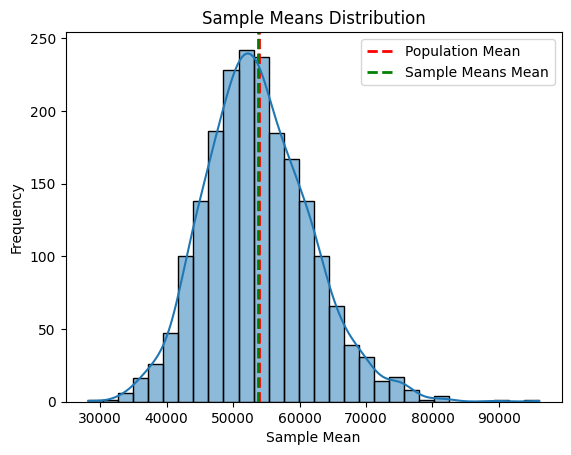

In [8]:
# lets plot the sample means distribution
sample_means = []
for _ in range(2000):
    sample = np.random.choice(salary, 50)
    sample_means.append(np.mean(sample))

# lets plot sample mean and population mean
plt.axvline(np.mean(salary), color='r', linestyle='dashed', linewidth=2, label='Population Mean')
plt.axvline(np.mean(sample_means), color='g', linestyle='dashed', linewidth=2, label='Sample Means Mean')
sns.histplot(sample_means, bins=30, kde=True)
plt.title('Sample Means Distribution')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [9]:
# Basically in CLT, we are saying that
# No matter what the population distribution is,
#  the distribution of the sample means will be approximately normal
#  if the sample size is sufficiently large (usually n > 30).

# This is a powerful concept because it allows us to make inferences about population parameters
#  using the properties of the normal distribution, even when the population itself is not normally distributed

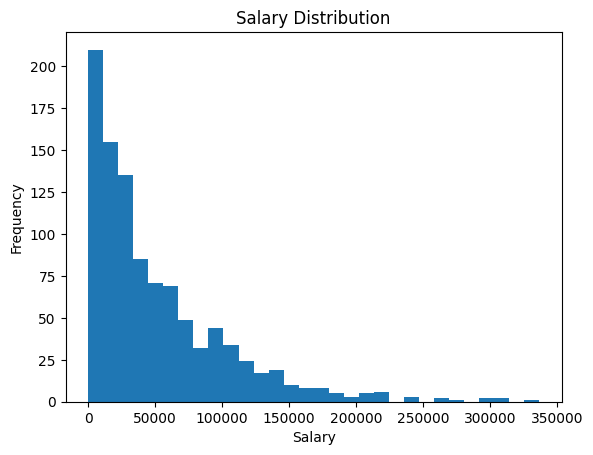

In [10]:
salary = np.random.exponential(scale=50000, size=1000)
plt.hist(salary, bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

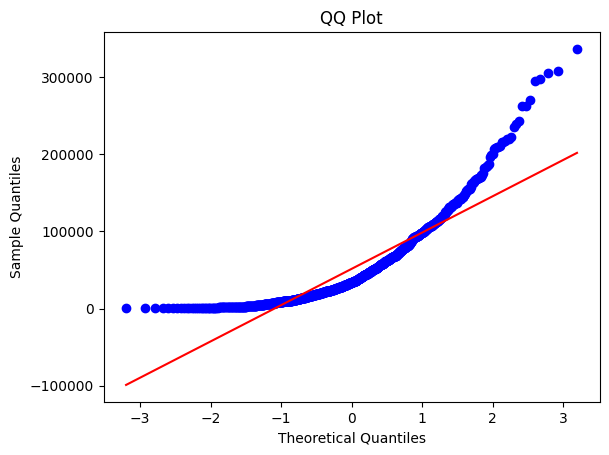

In [11]:
# QQ plot
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(salary, dist="norm", plot=plt)
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

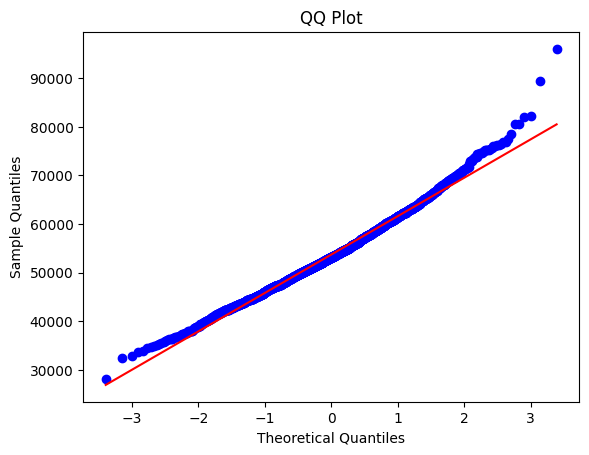

In [12]:
stats.probplot(sample_means, dist="norm", plot=plt)
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

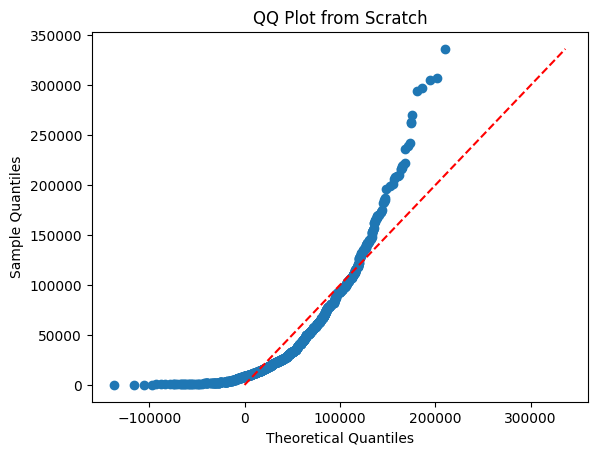

In [13]:
# Assignment  1 : Implement QQ plot from scratch
# Assignemnt  2 : Change mean to median in CLT example and observe the changes
import numpy as np
import matplotlib.pyplot as plt

# first sort the data
sorted_data = np.sort(salary)

# percentiles
n = len(sorted_data)
percentiles = (np.arange(1, n + 1) - 0.5) / n

# lets take normal distribution 
y = np.random.normal(loc=np.mean(salary), scale=np.std(salary), size=n)
y_sorted = np.sort(y)
# calculate the theoretical quantiles
theoretical_quantiles = np.percentile(y_sorted, percentiles * 100)
# 45 degree line
max_val = max(max(theoretical_quantiles), max(sorted_data))
plt.plot([0, max_val], [0, max_val], color='r', linestyle='--', label='45 Degree Line')
# plot the QQ plot
plt.scatter(theoretical_quantiles, sorted_data)
plt.title('QQ Plot from Scratch')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()  

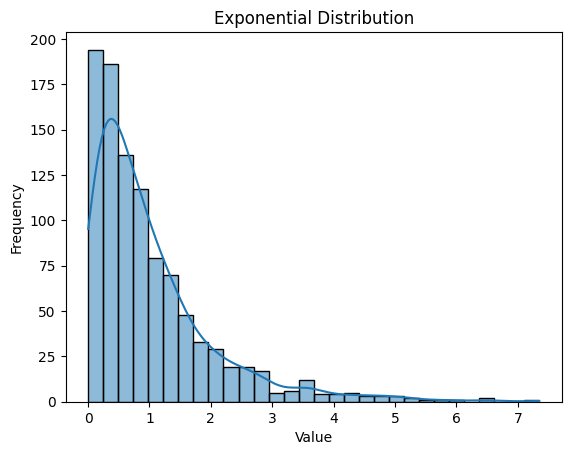

In [14]:
# lets generate exponential data 
data = np.random.exponential(scale=1.0, size=1000)
sns.histplot(data, bins=30, kde=True)
plt.title('Exponential Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

Fitted Lambda :  0.23781296820768622


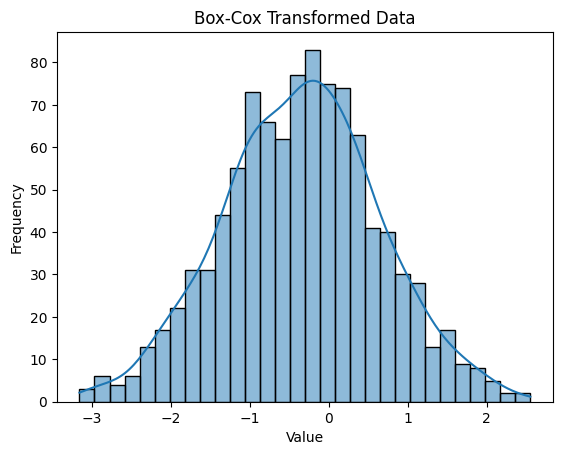

In [16]:
# Pareto Distribution --> Normal distribution
from scipy.stats import boxcox
boxcox_data, fitted_lambda = boxcox(data)
print('Fitted Lambda : ', fitted_lambda)
sns.histplot(boxcox_data, bins=30, kde=True)
plt.title('Box-Cox Transformed Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

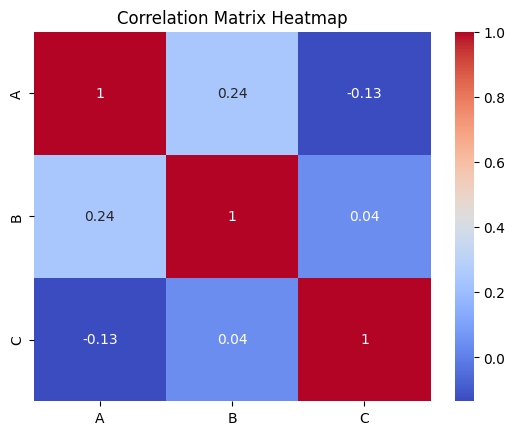

In [17]:
# lets create random pandas data to show corr
import pandas as pd
df = pd.DataFrame({
    'A': np.random.rand(100),
    'B': np.random.rand(100),
    'C': np.random.rand(100)
})
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()


In [ ]:
# Assignment 1:
# Compute covariance from scratch
# create dummy data and then compute covariance matrix

In [40]:
# data for hypothesis testing : need to fix it 
import numpy as np
from scipy import stats
height_a = np.random.normal(loc=65, scale=5, size=100)
height_b = np.random.normal(loc=67, scale=10, size=100)


# define t-statistic function
def t_statistic(sample1, sample2):
    mean1 = np.mean(sample1)
    mean2 = np.mean(sample2)
    diff = mean1 - mean2
    # no difference in means
    if abs(diff) < 1e-5:
        return 0
    return diff


# # define my null hypothesis function
def null_hypothesis(sample1, sample2, num_simulations=1000):
    combined = np.concatenate([sample1, sample2])
    count = 0
    observed_t_stat = t_statistic(sample1, sample2)
    # 0 means no difference
    for _ in range(num_simulations):
        np.random.shuffle(combined)
        new_sample1 = combined[:len(sample1)]
        new_sample2 = combined[len(sample2):]
        sim_t_stat = t_statistic(new_sample1, new_sample2)
        if abs(sim_t_stat) >= abs(observed_t_stat):
            count += 1
    p_value = count / num_simulations
    return p_value
# compute p-value


p_value = null_hypothesis(height_a, height_b)

print('P-Value : ', p_value)


P-Value :  0.353


In [ ]:
from scipy import stats
height_a = np.random.normal(loc=65, scale=5, size=100)
height_b = np.random.normal(loc=35, scale=11, size=100)

t_stat, p_value = stats.ttest_ind(height_a, height_b)
print('T-Statistic : ', t_stat)
print('P-Value : ', p_value)

# if p_value < 0.05:
#     print('Reject the null hypothesis')
# else:
#     print('Accept the null hypothesis')

# Please read below blogs
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
# https://medium.com/@amanatulla1606/a-comprehensive-guide-to-hypothesis-testing-understanding-methods-and-applications-5e20dffce791

T-Statistic :  25.76714518865582
P-Value :  3.684911245288842e-65


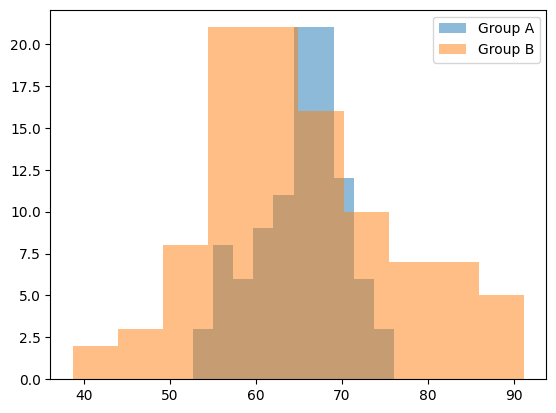

In [43]:
height_a = np.random.normal(loc=65, scale=5, size=100)
height_b = np.random.normal(loc=65, scale=11, size=100)

import matplotlib.pyplot as plt

plt.hist(height_a, alpha=0.5, label='Group A')
plt.hist(height_b, alpha=0.5, label='Group B')
plt.legend()
plt.show()

In [ ]:
## Why Box-Cox Transformation?
# Box-Cox transformation is used to 
# stabilize variance and make the data more normally distributed.


### Refrence 
- https://www.freecodecamp.org/news/normal-distribution-explained/
- https://www.analyticsvidhya.com/blog/2019/05/statistics-101-introduction-central-limit-theorem/
- https://www.statlect.com/fundamentals-of-probability/Chebyshev-inequality
- https://www.statisticshowto.com/probability-and-statistics/normal-distributions/box-cox-transformation/
- https://www.kaggle.com/code/utsavsarkar/statistical-analysis/notebook